# Reversible-Jump MCMC Seismic Tomography
### Transdimensional Bayesian Inversion with Voronoi Parametrisation

This notebook implements the **reversible-jump Markov chain Monte Carlo (rj-MCMC)**
seismic tomography algorithm of **Bodin & Sambridge (2009, *Geophys. J. Int.*)** and
applies it to the surrogate straight-ray dataset generated by `generate_surrogate_dataset.py`.

---

#### Key ideas

| Concept | Details |
|---------|---------|
| **Model** | Voronoi partition with *n* nuclei, each cell carrying a constant slowness *s* |
| **Unknowns** | Nucleus positions **c** = {c₁…cₙ}, slowness vector **v** = {v₁…vₙ}, *and* the dimension *n* itself |
| **Prior** | Uniform on *n* ∈ [N_min, N_max]; uniform on positions; uniform on slowness ∈ [S_min, S_max] |
| **Likelihood** | Gaussian: *p(d&#124;m) ∝ exp(−φ(m)/2)* with *φ = ‖d_obs − G(m)‖²/σ²* |
| **Sampler** | rj-MCMC with four move types: slowness-update, nucleus-move, birth, death |
| **Output** | Ensemble of models → pointwise mean (solution) and std (uncertainty) |

---

#### Notebook structure

1. Load surrogate dataset  
2. Pre-compute ray sample points  
3. Voronoi forward model (cached, vectorised)  
4. Bayesian framework — prior & likelihood  
5. rj-MCMC move types (eqs 17-36 of Bodin & Sambridge 2009)  
6. Main sampler with 2-stage delayed rejection  
7. Run MCMC  
8. Convergence diagnostics  
9. Ensemble → mean & uncertainty maps  
10. Results & comparison with true model


## 1 · Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Polygon as MplPoly
from scipy.spatial import cKDTree
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import norm as spnorm
import time, warnings
warnings.filterwarnings('ignore')

# Global RNG — re-seeded inside the sampler for reproducibility
RNG = np.random.default_rng(42)

# ── Dark-theme plot style ──────────────────────────────────────────────────
DARK, PANEL, BORDER = '#0d1117', '#161b22', '#30363d'
TEXT, MUTED         = '#e6edf3', '#8b949e'

plt.rcParams.update({
    'figure.facecolor': DARK, 'axes.facecolor': PANEL,
    'axes.edgecolor':   BORDER, 'text.color': TEXT,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.labelcolor': MUTED,
})

print("Libraries loaded.")


Libraries loaded.


## 2 · Load Surrogate Dataset

The `.npz` archive was generated by `generate_surrogate_dataset.py` and contains:
- `d_obs` — noisy travel times (our observations)
- `d_true` — noise-free travel times (for validation only)
- `G` — ray-path matrix on the *regular* grid (not used directly here)
- `slowness_true` — ground-truth slowness field
- Sources, receivers, grid metadata


In [2]:
raw = np.load('data/surrogate_seismic_dataset_v2.npz')

d_obs         = raw['d_obs'].astype(np.float64)
d_true        = raw['d_true'].astype(np.float64)
sources       = raw['sources'].astype(np.float64)
receivers     = raw['receivers'].astype(np.float64)
slowness_true = raw['slowness_true'].astype(np.float64)
xc            = raw['xc'].astype(np.float64)
yc            = raw['yc'].astype(np.float64)
grid_params   = raw['grid_params']
noise_std     = float(raw['noise_std'])

Nx, Ny  = int(grid_params[0]), int(grid_params[1])
Lx, Ly  = grid_params[2], grid_params[3]
s0      = grid_params[6]          # background slowness [s/km]
XX, YY  = np.meshgrid(xc, yc)    # for plotting on regular grid

n_src  = len(sources)
n_rec  = len(receivers)
n_rays = n_src * n_rec

print(f"Domain       : {Lx:.0f} × {Ly:.0f} km")
print(f"Regular grid : {Nx}×{Ny} = {Nx*Ny} cells  (used for surrogate generation only)")
print(f"Sources      : {n_src}   Receivers : {n_rec}   Rays : {n_rays}")
print(f"Background   : s₀ = {s0:.4f} s/km  →  v₀ = {1/s0:.1f} km/s")
print(f"Noise σ      : {noise_std:.6f} s  ({noise_std/d_obs.mean()*100:.2f} % of mean t)")


Domain       : 50 × 50 km
Regular grid : 50×50 = 2500 cells  (used for surrogate generation only)
Sources      : 48   Receivers : 48   Rays : 2304
Background   : s₀ = 0.3333 s/km  →  v₀ = 3.0 km/s
Noise σ      : 0.058521 s  (0.50 % of mean t)


## 3 · Pre-compute Ray Sample Points

For the Voronoi forward model we need the physical coordinates of each
ray segment — not just the G matrix built on the regular grid.

For every source–receiver pair we sample the straight ray at a fine
step (≈ `OVERSAMPLE` pts / km) and store the segment midpoints.
All points are flattened into a single array (`all_pts_flat`) and a
companion `ray_indices` array maps each point back to its ray — enabling
a **single** batched KDTree query per forward call.


In [3]:
OVERSAMPLE = 5   # sample points per km  (increase for higher accuracy)

pts_list  = []   # (n_pts_k, 2) per ray
segl_list = []   # segment length per ray

for sx, sy in sources:
    for rx, ry in receivers:
        ray_len  = np.hypot(rx - sx, ry - sy)
        n_steps  = max(int(ray_len * OVERSAMPLE), 8)
        ts       = np.linspace(0.0, 1.0, n_steps + 1)
        ts_mid   = 0.5 * (ts[:-1] + ts[1:])
        xm       = sx + ts_mid * (rx - sx)
        ym       = sy + ts_mid * (ry - sy)
        # Clip to domain interior
        inside   = (xm >= 0) & (xm <= Lx) & (ym >= 0) & (ym <= Ly)
        xm, ym   = xm[inside], ym[inside]
        if len(xm) == 0:          # degenerate: source or receiver on boundary
            xm = np.array([0.5 * (sx + rx)])
            ym = np.array([0.5 * (sy + ry)])
        pts_list.append(np.column_stack([xm, ym]))
        segl_list.append(ray_len / n_steps)

# ── Flatten for vectorised batch processing ─────────────────────────────────
all_pts_flat = np.vstack(pts_list)                             # (total_pts, 2)
ray_pt_counts = np.array([len(p) for p in pts_list])          # (n_rays,)
ray_indices   = np.repeat(np.arange(n_rays), ray_pt_counts)   # (total_pts,)
seg_lens_arr  = np.array(segl_list)                            # (n_rays,)

total_pts = len(all_pts_flat)
print(f"Total sample points  : {total_pts:,}")
print(f"Average pts / ray    : {total_pts / n_rays:.1f}")
print(f"Estimated memory     : {all_pts_flat.nbytes / 1e6:.1f} MB")


Total sample points  : 421,984
Average pts / ray    : 183.2
Estimated memory     : 6.8 MB


## 4 · Voronoi Forward Model

Given a set of $n$ nuclei $\{\mathbf{c}_i\}$ and associated slowness values
$\{s_i\}$, the travel time of ray $j$ is:

$$t_j = \delta l_j \sum_{k \in \text{ray}_j} s\bigl(\mathbf{x}_k\bigr)
       = \delta l_j \sum_{k \in \text{ray}_j} s_{R(\mathbf{x}_k)}$$

where $R(\mathbf{x}_k)$ is the index of the Voronoi cell (nearest nucleus)
containing sample point $\mathbf{x}_k$, and $\delta l_j$ is the sub-segment
length.

**Caching optimisation** — consecutive *slowness-update* moves leave the
Voronoi tessellation unchanged.  We cache the KDTree cell-assignment array
and only rebuild it when the nucleus positions actually change.


In [4]:
# ── Cached KDTree cell-assignment ────────────────────────────────────────────
_cache_key  = None    # hash of current nuclei array
_cache_asgn = None    # (total_pts,) int array

def _cell_assignments(nuclei: np.ndarray) -> np.ndarray:
    """Return Voronoi cell index for every sample point (with caching)."""
    global _cache_key, _cache_asgn
    key = nuclei.tobytes()
    if key != _cache_key:
        tree        = cKDTree(nuclei)
        _, asgn     = tree.query(all_pts_flat)
        _cache_key  = key
        _cache_asgn = asgn
    return _cache_asgn


def make_ghost_nuclei(n_per_edge: int = 8, margin: float = 1.5) -> np.ndarray:
    """
    Create a ring of ghost nuclei *outside* the domain boundary.

    These are fixed at background slowness s0 and are never perturbed.
    They clip boundary Voronoi cells, preventing unconstrained slowness
    from accumulating at the domain edges.

    Parameters
    ----------
    n_per_edge : number of ghost nuclei along each of the 4 edges
    margin     : distance outside the domain [km]
    """
    pts = []
    xs  = np.linspace(-margin, Lx + margin, n_per_edge + 2)
    ys  = np.linspace(-margin, Ly + margin, n_per_edge + 2)

    # Bottom and top edges
    for x in xs:
        pts.append([x, -margin])           # below
        pts.append([x,  Ly + margin])      # above
    # Left and right edges (skip corners already added)
    for y in ys[1:-1]:
        pts.append([-margin,      y])      # left
        pts.append([Lx + margin,  y])      # right

    return np.array(pts)


# Pre-build ghost nuclei (fixed for the entire chain)
GHOST_NUC = make_ghost_nuclei(n_per_edge=10, margin=1.5)
N_GHOST   = len(GHOST_NUC)

def assemble_nuclei(nuclei: np.ndarray) -> np.ndarray:
    """Concatenate mobile nuclei with the fixed ghost ring."""
    return np.vstack([nuclei, GHOST_NUC])

def assemble_slowness(s_vals: np.ndarray) -> np.ndarray:
    """Append background slowness for every ghost nucleus."""
    return np.concatenate([s_vals, np.full(N_GHOST, s0)])


def forward_model(nuclei: np.ndarray, s_vals: np.ndarray) -> np.ndarray:
    """
    Compute straight-ray travel times for a Voronoi slowness model.

    Parameters
    ----------
    nuclei : (n, 2)  – mobile nucleus coordinates [km]
    s_vals : (n,)    – slowness per mobile cell [s/km]

    Returns
    -------
    t : (n_rays,)  – predicted travel times [s]
    """
    full_nuc  = assemble_nuclei(nuclei)
    full_s    = assemble_slowness(s_vals)
    asgn      = _cell_assignments(full_nuc)         # (total_pts,) cached
    s_at_pts  = full_s[asgn]                        # (total_pts,)
    t = np.bincount(ray_indices,
                    weights=s_at_pts,
                    minlength=n_rays) * seg_lens_arr
    return t


def log_likelihood(t_pred: np.ndarray) -> float:
    """Gaussian log-likelihood:  −½ Σ [(t_pred−t_obs)/σ]²"""
    return -0.5 * np.sum(((t_pred - d_obs) / noise_std) ** 2)


# ── Sanity check ─────────────────────────────────────────────────────────────
_nuc_test = np.array([[Lx / 2, Ly / 2]])
_s_test   = np.array([s0])
_t_test   = forward_model(_nuc_test, _s_test)
print(f"Ghost nuclei  : {N_GHOST} (ring around domain boundary)")
print(f"Single-cell homogeneous test")
print(f"  Predicted mean t  : {_t_test.mean():.4f} s")
print(f"  Observed  mean t  : {d_obs.mean():.4f} s")


Ghost nuclei  : 44 (ring around domain boundary)
Single-cell homogeneous test
  Predicted mean t  : 12.2357 s
  Observed  mean t  : 11.7014 s


## 5 · Bayesian Framework & Hyperparameters

### Prior  (eq 14 of Bodin & Sambridge 2009)

$$p(\mathbf{m}) = \frac{n!\,(N-n)!}{N!\,\Delta s^n\,\Delta n}
\quad \text{if } n \in [N_{\min}, N_{\max}] \text{ and }
\forall s_i \in [s_{\min}, s_{\max}]$$

In practice $N \to \infty$ (continuous nuclei placement) and the $N$-dependent
factors cancel in the acceptance ratio — see Appendix B of the paper.

### Proposal standard deviations

| Symbol | Role | Default |
|--------|------|---------|
| `SIG_S` | slowness perturbation | 0.006 s/km |
| `SIG_S2` | birth slowness proposal ($\sigma_2$) | 0.012 s/km |
| `SIG_C` | nucleus position perturbation | 2.0 km |
| `SIG_S_DR`, `SIG_C_DR` | delayed-rejection (stage 2) | × 0.25 |

Adjust these if acceptance rates are too low or too high (target ~25–50 %).


In [5]:
# ── Slowness prior bounds ─────────────────────────────────────────────────────
S_MIN   = 0.18          # v_max ≈ 5.6 km/s
S_MAX   = 0.62          # v_min ≈ 1.6 km/s
DELTA_S = S_MAX - S_MIN

# ── Dimension prior ───────────────────────────────────────────────────────────
N_MIN, N_MAX = 2, 200

# ── Proposal standard deviations ──────────────────────────────────────────────
SIG_S    = 0.006    # slowness update
SIG_S2   = 0.012    # birth proposal  (σ₂ in Bodin & Sambridge 2009)
SIG_C    = 2.0      # nucleus move [km]

# Stage-2 delayed rejection (halved variance)
SIG_S_DR = SIG_S  * 0.25
SIG_C_DR = SIG_C  * 0.25

# ── Helper: slowness at an arbitrary point in current tessellation ─────────────
def slowness_at(x: float, y: float,
                nuclei: np.ndarray, s_vals: np.ndarray) -> float:
    """Return slowness of the Voronoi cell containing (x, y).
    Uses the full assembled (mobile + ghost) nuclei so birth proposals
    near the boundary get the correct local slowness reference.
    """
    full_nuc = assemble_nuclei(nuclei)
    full_s   = assemble_slowness(s_vals)
    d2 = (full_nuc[:, 0] - x) ** 2 + (full_nuc[:, 1] - y) ** 2
    return float(full_s[np.argmin(d2)])

print(f"Slowness bounds : [{S_MIN}, {S_MAX}] s/km  →  velocities [{1/S_MAX:.1f}, {1/S_MIN:.1f}] km/s")
print(f"Dimension prior : n ∈ [{N_MIN}, {N_MAX}]")
print(f"Proposals       : σ_s = {SIG_S}  σ_s2 = {SIG_S2}  σ_c = {SIG_C} km")


Slowness bounds : [0.18, 0.62] s/km  →  velocities [1.6, 5.6] km/s
Dimension prior : n ∈ [2, 200]
Proposals       : σ_s = 0.006  σ_s2 = 0.012  σ_c = 2.0 km


## 6 · rj-MCMC Move Types

Four proposal types follow Table 1 / Section 2.7 of the paper.

### Fixed-dimension moves (proposal ratio = 1 → eq 32)

**Slowness update** — perturb $s_k$ of a randomly chosen cell by
$\mathcal{N}(0, \sigma_s^2)$.  The Voronoi tessellation is unchanged so
the cached cell-assignment is reused.

**Nucleus move** — perturb the position of a randomly chosen nucleus by
$\mathcal{N}(\mathbf{0}, \sigma_c^2 \mathbf{I})$.  Velocity moves with
the nucleus.

### Transdimensional moves

**Birth** (eq 35) — add nucleus at position $(c_x, c_y) \sim U([0,L_x]\times[0,L_y])$,
assign slowness $s_{n+1} = s_i + u_v$, $u_v \sim \mathcal{N}(0,\sigma_2^2)$:

$$\log\alpha_{\text{birth}} = \log\!\frac{\sigma_2\sqrt{2\pi}}{\Delta s}
  + \frac{u_v^2}{2\sigma_2^2} + \log\!\frac{p(\mathbf{d}|\mathbf{m}')}{p(\mathbf{d}|\mathbf{m})}$$

**Death** (eq 36) — remove a random nucleus; acceptance is the inverse ratio:

$$\log\alpha_{\text{death}} = \log\!\frac{\Delta s}{\sigma_2\sqrt{2\pi}}
  - \frac{(s_i - s_j')^2}{2\sigma_2^2} + \log\!\frac{p(\mathbf{d}|\mathbf{m}')}{p(\mathbf{d}|\mathbf{m})}$$


In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  MOVE 1 — Slowness update  (fixed dimension)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def move_slowness(nuclei, s_vals, logL, sigma=SIG_S):
    """
    Perturb the slowness of one randomly chosen Voronoi cell.
    Tessellation unchanged → KDTree cache always hit.
    """
    k     = int(RNG.integers(len(s_vals)))
    ds    = float(RNG.normal(0.0, sigma))
    s_new = s_vals[k] + ds
    if not (S_MIN <= s_new <= S_MAX):
        return nuclei, s_vals, logL, False
    s_prop    = s_vals.copy();  s_prop[k] = s_new
    t_prop    = forward_model(nuclei, s_prop)
    logL_prop = log_likelihood(t_prop)
    if np.log(RNG.random() + 1e-300) < logL_prop - logL:
        return nuclei, s_prop, logL_prop, True
    return nuclei, s_vals, logL, False


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  MOVE 2 — Nucleus position move  (fixed dimension)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def move_nucleus(nuclei, s_vals, logL, sigma=SIG_C):
    """
    Perturb the 2-D position of one randomly chosen nucleus.
    Slowness value travels with the nucleus; tessellation rebuilt.
    """
    k       = int(RNG.integers(len(nuclei)))
    new_pos = nuclei[k] + RNG.normal(0.0, sigma, 2)
    # Reject if outside domain
    if not (0.0 < new_pos[0] < Lx and 0.0 < new_pos[1] < Ly):
        return nuclei, s_vals, logL, False
    nuc_prop    = nuclei.copy();  nuc_prop[k] = new_pos
    t_prop      = forward_model(nuc_prop, s_vals)
    logL_prop   = log_likelihood(t_prop)
    if np.log(RNG.random() + 1e-300) < logL_prop - logL:
        return nuc_prop, s_vals, logL_prop, True
    return nuclei, s_vals, logL, False


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  MOVE 3 — Birth  (n → n+1,  eq 35)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
_LOG_SIG2_SQRT2PI = np.log(SIG_S2 * np.sqrt(2.0 * np.pi))

def move_birth(nuclei, s_vals, logL):
    """
    Add one Voronoi nucleus at a uniformly random position.
    Slowness for the new cell is drawn from N(s_local, σ₂²).
    Acceptance follows eq 35 of Bodin & Sambridge (2009).
    """
    n = len(nuclei)
    if n >= N_MAX:
        return nuclei, s_vals, logL, False

    # Random position
    cx, cy  = float(RNG.uniform(0.0, Lx)), float(RNG.uniform(0.0, Ly))
    # Slowness of the cell that currently owns this location
    s_local = slowness_at(cx, cy, nuclei, s_vals)
    # Draw new slowness
    u_v     = float(RNG.normal(0.0, SIG_S2))
    s_birth = s_local + u_v
    if not (S_MIN <= s_birth <= S_MAX):
        return nuclei, s_vals, logL, False

    nuc_prop  = np.vstack([nuclei, [cx, cy]])
    s_prop    = np.append(s_vals, s_birth)
    t_prop    = forward_model(nuc_prop, s_prop)
    logL_prop = log_likelihood(t_prop)

    # log-acceptance (eq 35):
    #   log α = log(σ₂√2π / Δs)  +  u_v²/(2σ₂²)  +  ΔlogL
    log_alpha = (_LOG_SIG2_SQRT2PI - np.log(DELTA_S)
                 + u_v**2 / (2.0 * SIG_S2**2)
                 + logL_prop - logL)

    if np.log(RNG.random() + 1e-300) < log_alpha:
        return nuc_prop, s_prop, logL_prop, True
    return nuclei, s_vals, logL, False


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  MOVE 4 — Death  (n → n−1,  eq 36)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def move_death(nuclei, s_vals, logL):
    """
    Remove a randomly chosen nucleus.
    Acceptance is the reverse of the birth step (eq 36).
    """
    n = len(nuclei)
    if n <= N_MIN:
        return nuclei, s_vals, logL, False

    k          = int(RNG.integers(n))
    s_removed  = float(s_vals[k])
    pos_removed = nuclei[k].copy()

    nuc_prop  = np.delete(nuclei, k, axis=0)
    s_prop    = np.delete(s_vals, k)
    t_prop    = forward_model(nuc_prop, s_prop)
    logL_prop = log_likelihood(t_prop)

    # Slowness at the removed nucleus position in the *new* tessellation
    s_after = slowness_at(pos_removed[0], pos_removed[1], nuc_prop, s_prop)

    # log-acceptance (eq 36):
    #   log α = log(Δs / (σ₂√2π))  −  (s_rem − s_after)²/(2σ₂²)  +  ΔlogL
    log_alpha = (np.log(DELTA_S) - _LOG_SIG2_SQRT2PI
                 - (s_removed - s_after)**2 / (2.0 * SIG_S2**2)
                 + logL_prop - logL)

    if np.log(RNG.random() + 1e-300) < log_alpha:
        return nuc_prop, s_prop, logL_prop, True
    return nuclei, s_vals, logL, False


print("All four move types defined.")


All four move types defined.


## 7 · Delayed Rejection (Tierney & Mira 1999)

For the fixed-dimension moves we implement a simplified 2-stage delayed
rejection scheme (Appendix A of the paper).  On first rejection, a
second move is proposed with a **smaller** variance.  This increases the
overall acceptance rate and reduces sensitivity to the proposal tuning.

> For rigorously correct detailed balance at stage 2 the acceptance
> probability must include a correction factor (eq A2).  Here we use the
> simplified version — correct detailed balance at stage 1 is unaffected.


In [7]:
def dr_slowness(nuclei, s_vals, logL):
    """Slowness update with 2-stage delayed rejection."""
    nuc, s, L, acc = move_slowness(nuclei, s_vals, logL, sigma=SIG_S)
    if acc:
        return nuc, s, L, True
    # Stage 2: smaller variance
    nuc, s, L, acc = move_slowness(nuclei, s_vals, logL, sigma=SIG_S_DR)
    return nuc, s, L, acc


def dr_nucleus(nuclei, s_vals, logL):
    """Nucleus move with 2-stage delayed rejection."""
    nuc, s, L, acc = move_nucleus(nuclei, s_vals, logL, sigma=SIG_C)
    if acc:
        return nuc, s, L, True
    nuc, s, L, acc = move_nucleus(nuclei, s_vals, logL, sigma=SIG_C_DR)
    return nuc, s, L, acc

print("Delayed rejection wrappers ready.")


Delayed rejection wrappers ready.


## 8 · Main rj-MCMC Sampler

**Move schedule** following Bodin & Sambridge (2009):
- *Even* steps → slowness update (with delayed rejection)  
- *Odd* steps → uniformly random among {birth, death, nucleus-move}

The chain stores post-burn-in thinned samples as `(nuclei, slowness)` pairs.


In [8]:
def rj_mcmc(n_steps: int,
            n_burn:  int,
            thin:    int,
            n_init:  int = 8,
            seed:    int = 0) -> tuple:
    """
    Reversible-Jump MCMC seismic tomography.

    Parameters
    ----------
    n_steps : total chain length (including burn-in)
    n_burn  : steps to discard as burn-in
    thin    : keep every *thin*-th post-burn-in model
    n_init  : initial number of Voronoi cells
    seed    : RNG seed

    Returns
    -------
    ensemble : list of (nuclei_array, slowness_array) tuples
    diag     : dict — n_cells trace, logL trace, acceptance counts
    """
    global RNG
    RNG = np.random.default_rng(seed)

    # ── Initialisation ──────────────────────────────────────────────────────
    nuclei = RNG.uniform(low=[0, 0], high=[Lx, Ly], size=(n_init, 2))
    s_vals = RNG.uniform(s0 - 0.01, s0 + 0.01, size=n_init)
    t_cur  = forward_model(nuclei, s_vals)
    logL   = log_likelihood(t_cur)

    # ── Storage ──────────────────────────────────────────────────────────────
    ensemble    = []
    n_cells_log = np.zeros(n_steps, dtype=np.int32)
    logL_log    = np.zeros(n_steps)

    acc = dict(s=0, move=0, birth=0, death=0)
    tot = dict(s=0, move=0, birth=0, death=0)

    t_wall = time.time()
    print_every = max(n_steps // 10, 1)

    for step in range(n_steps):

        # ── Choose and apply move ───────────────────────────────────────────
        if step % 2 == 0:
            # ── Slowness update (with DR) ───────────────────────────────────
            tot['s'] += 1
            nuclei, s_vals, logL, a = dr_slowness(nuclei, s_vals, logL)
            if a: acc['s'] += 1

        else:
            # ── Geometry step: birth / death / nucleus-move ─────────────────
            choice = int(RNG.integers(3))
            if choice == 0:
                tot['birth'] += 1
                nuclei, s_vals, logL, a = move_birth(nuclei, s_vals, logL)
                if a: acc['birth'] += 1
            elif choice == 1:
                tot['death'] += 1
                nuclei, s_vals, logL, a = move_death(nuclei, s_vals, logL)
                if a: acc['death'] += 1
            else:
                tot['move'] += 1
                nuclei, s_vals, logL, a = dr_nucleus(nuclei, s_vals, logL)
                if a: acc['move'] += 1

        # ── Bookkeeping ─────────────────────────────────────────────────────
        n_cells_log[step] = len(nuclei)
        logL_log[step]    = logL

        # Collect post-burn-in thinned sample
        if step >= n_burn and (step - n_burn) % thin == 0:
            ensemble.append((nuclei.copy(), s_vals.copy()))

        # Progress report
        if (step + 1) % print_every == 0:
            elapsed = time.time() - t_wall
            eta     = elapsed / (step + 1) * (n_steps - step - 1)
            print(f"  {(step+1)/n_steps*100:5.1f}%  step {step+1:>7,}  "
                  f"logL = {logL:10.1f}  n_cells = {len(nuclei):3d}  "
                  f"ETA {eta:5.0f}s")

    elapsed = time.time() - t_wall
    print(f"\n  Finished in {elapsed:.1f} s  ({elapsed/n_steps*1e3:.2f} ms/step)")
    print(f"  Ensemble size: {len(ensemble)}")

    print("\n  ── Acceptance rates ─────────────────────────────────")
    for k in ('s', 'move', 'birth', 'death'):
        if tot[k] > 0:
            print(f"  {k:7s}: {acc[k]/tot[k]*100:5.1f}%  ({acc[k]}/{tot[k]})")

    diag = dict(n_cells=n_cells_log, logL=logL_log,
                n_burn=n_burn, thin=thin, acc=acc, tot=tot)
    return ensemble, diag

print("Sampler function defined.")


Sampler function defined.


## 9 · Run the Sampler

> **Runtime guide**
>
> | N_STEPS | Approx. time | Quality |
> |---------|-------------|---------|
> | 50 000  | ~5–10 min   | Quick look |
> | 150 000 | ~15–30 min  | Good convergence |
> | 500 000 | ~60–90 min  | Publication quality |
>
> Increase `N_STEPS` for better results.  The ensemble quality scales roughly
> as $1/\sqrt{N_{\text{ensemble}}}$ after burn-in.


In [9]:
# ── Run parameters ────────────────────────────────────────────────────────────
N_STEPS =  50_000      # ← Adjust this to trade quality for speed
N_BURN  =  20_000      # Discard first 20 % as burn-in
THIN    =     10      # Keep every 10th post-burn-in sample
N_INIT  =      8      # Starting number of Voronoi cells

print(f"Chain length  : {N_STEPS:,}  (burn-in {N_BURN:,})")
print(f"Expected ensemble size : {(N_STEPS-N_BURN)//THIN:,} models")
print()

ensemble, diag = rj_mcmc(
    n_steps=N_STEPS, n_burn=N_BURN, thin=THIN, n_init=N_INIT, seed=7
)


Chain length  : 50,000  (burn-in 20,000)
Expected ensemble size : 3,000 models



KeyboardInterrupt: 

## 10 · Convergence Diagnostics

We monitor:
- **Log-likelihood trace** — should stabilise after burn-in
- **n_cells trace** — dimension should fluctuate around a stable value
- **Posterior p(n | d_obs)** — histogram of ensemble dimension
- **Running mean logL** — should flatten post burn-in


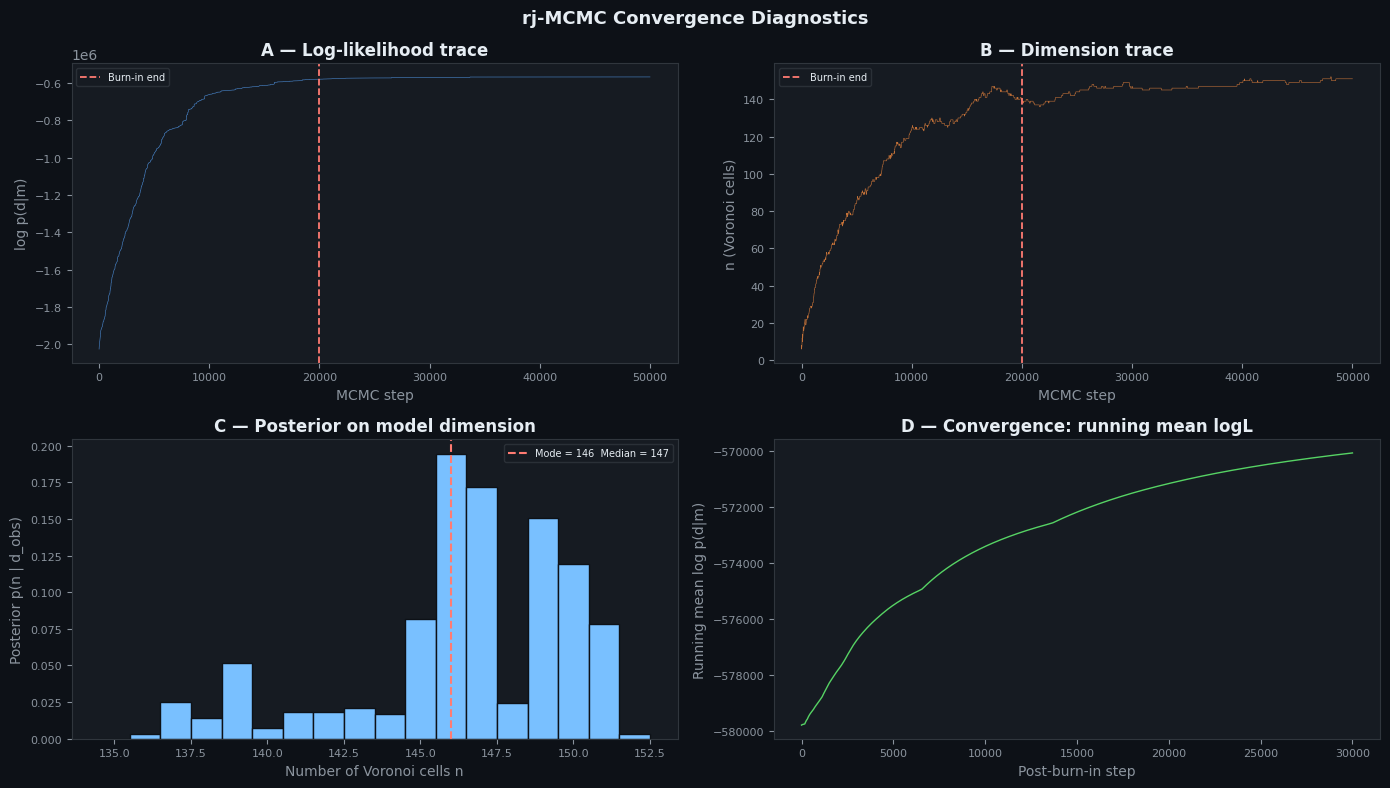

Saved → figures/convergence.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor=DARK)

for ax in axes.flat:
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_color(BORDER)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.xaxis.label.set_color(MUTED); ax.yaxis.label.set_color(MUTED)
    ax.title.set_color(TEXT)

burn_kw = dict(color='#ff7b72', lw=1.3, ls='--', label='Burn-in end')
steps   = np.arange(N_STEPS)

# A: Log-likelihood chain
ax = axes[0, 0]
ax.plot(steps, diag['logL'], color='#58a6ff', lw=0.4, alpha=0.8)
ax.axvline(N_BURN, **burn_kw)
ax.set_xlabel('MCMC step'); ax.set_ylabel('log p(d|m)')
ax.set_title('A — Log-likelihood trace', fontweight='bold')
ax.legend(fontsize=7, facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)

# B: n_cells chain
ax = axes[0, 1]
ax.plot(steps, diag['n_cells'], color='#f0883e', lw=0.4, alpha=0.8)
ax.axvline(N_BURN, **burn_kw)
ax.set_xlabel('MCMC step'); ax.set_ylabel('n (Voronoi cells)')
ax.set_title('B — Dimension trace', fontweight='bold')
ax.legend(fontsize=7, facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)

# C: Posterior on n
post_n = diag['n_cells'][N_BURN:]
ax = axes[1, 0]
bins = np.arange(max(1, post_n.min()-1), post_n.max()+2) - 0.5
ax.hist(post_n, bins=bins, color='#79c0ff', edgecolor=DARK, lw=0.4, density=True)
mode_n = int(np.bincount(post_n).argmax())
ax.axvline(mode_n, color='#ff7b72', lw=1.5, ls='--',
           label=f'Mode = {mode_n}  Median = {int(np.median(post_n))}')
ax.set_xlabel('Number of Voronoi cells n'); ax.set_ylabel('Posterior p(n | d_obs)')
ax.set_title('C — Posterior on model dimension', fontweight='bold')
ax.legend(fontsize=7, facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)

# D: Running mean of log-likelihood (post burn-in)
post_logL   = diag['logL'][N_BURN:]
running_mean = np.cumsum(post_logL) / (np.arange(len(post_logL)) + 1)
ax = axes[1, 1]
ax.plot(running_mean, color='#56d364', lw=1.0)
ax.set_xlabel('Post-burn-in step'); ax.set_ylabel('Running mean log p(d|m)')
ax.set_title('D — Convergence: running mean logL', fontweight='bold')

fig.suptitle('rj-MCMC Convergence Diagnostics', color=TEXT,
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('figures/convergence.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()
print("Saved → figures/convergence.png")


## 11 · Ensemble → Mean & Uncertainty Maps

We project the ensemble of Voronoi models onto a fine regular grid
(Section 2.9 of the paper).  At each grid point we find the nearest
nucleus (i.e. the Voronoi cell owner) for every model and average:

$$\bar{s}(\mathbf{x}) = \frac{1}{K}\sum_{k=1}^{K} s_{R_k(\mathbf{x})}^{(k)},
\qquad
\sigma_s(\mathbf{x}) = \operatorname{std}_k\!\left[s_{R_k(\mathbf{x})}^{(k)}\right]$$

The averaging naturally smooths out unwarranted discontinuities while
reinforcing well-constrained features.


In [ ]:
def project_ensemble(ensemble, nx=80, ny=80):
    """
    Project Voronoi ensemble onto a fine regular grid.

    Ghost nuclei are included in each Voronoi query so boundary cells
    are correctly clipped. A hit-count mask is returned so un-sampled
    regions (zero ray coverage) can be excluded from the final maps.

    Returns
    -------
    xg, yg     : 1-D grid axes
    XG, YG     : 2-D grid meshes
    s_mean     : (ny, nx) pointwise mean slowness
    s_std      : (ny, nx) pointwise std (model uncertainty)
    hit_mask   : (ny, nx) bool — True where at least one ray passes through
    """
    xg = np.linspace(0.0, Lx, nx)
    yg = np.linspace(0.0, Ly, ny)
    XG, YG = np.meshgrid(xg, yg)
    query  = np.column_stack([XG.ravel(), YG.ravel()])   # (nx*ny, 2)

    K     = len(ensemble)
    stack = np.zeros((K, len(query)))

    for i, (nuc, s) in enumerate(ensemble):
        full_nuc = assemble_nuclei(nuc)
        full_s   = assemble_slowness(s)
        tree     = cKDTree(full_nuc)
        _, idx   = tree.query(query)
        stack[i] = full_s[idx]

    s_mean = stack.mean(0).reshape(ny, nx)
    s_std  = stack.std(0).reshape(ny, nx)

    # ── Ray hit-count mask ────────────────────────────────────────────────────
    # Build hit count on the same grid using the pre-computed ray sample points
    ix_all = np.clip(np.floor(all_pts_flat[:, 0] / (Lx / nx)).astype(int), 0, nx-1)
    iy_all = np.clip(np.floor(all_pts_flat[:, 1] / (Ly / ny)).astype(int), 0, ny-1)
    hit    = np.zeros((ny, nx), dtype=np.int32)
    np.add.at(hit, (iy_all, ix_all), 1)
    hit_mask = hit > 0

    return xg, yg, XG, YG, s_mean, s_std, hit_mask


print(f"Projecting {len(ensemble)} models onto 80×80 grid …")
import time
t0 = time.time()
xg, yg, XG, YG, s_mean, s_std, hit_mask = project_ensemble(ensemble, nx=80, ny=80)
print(f"  Done in {time.time()-t0:.1f} s")
print(f"  Covered grid cells : {hit_mask.sum()} / {hit_mask.size}  "
      f"({hit_mask.mean()*100:.1f} %)")


Projecting 3000 models onto 80×80 grid …
  Done in 24.0 s
  Covered grid cells : 6388 / 6400  (99.8 %)


## 12 · Results & Comparison with True Model

Six-panel figure:

| Panel | Content |
|-------|---------|
| A | True slowness field (ground truth) |
| B | rj-MCMC ensemble mean with example Voronoi overlay |
| C | Posterior uncertainty σ_s |
| D | Absolute error |mean − true| |
| E | Posterior p(n \| d) — model dimension |
| F | Data-fit residuals for the ensemble mean prediction |


Computing ensemble mean prediction …
  RMS residual: 1.29915 s  (noise σ = 0.05852 s)


AttributeError: 'Text' object has no property 'pad'

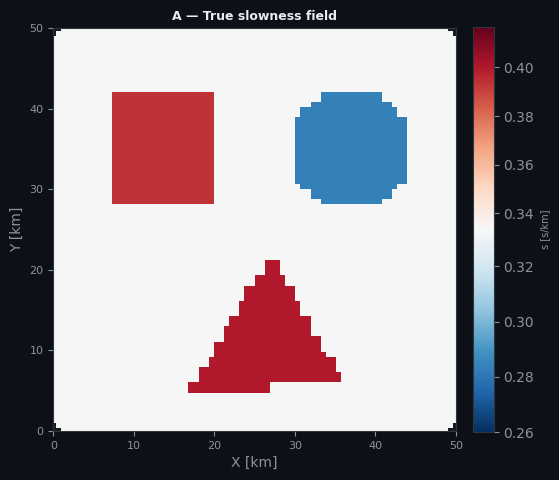

In [ ]:
# ── Interpolate true model onto fine grid ────────────────────────────────────
interp_fn  = RegularGridInterpolator((yc, xc), slowness_true,
                                      method='nearest', bounds_error=False,
                                      fill_value=s0)
s_true_fine = interp_fn(
    np.column_stack([YG.ravel(), XG.ravel()])
).reshape(YG.shape)

# ── Colour scale centred on background slowness ──────────────────────────────
s_lo   = s0 * 0.78;   s_hi = s0 * 1.25
norm   = TwoSlopeNorm(vmin=s_lo, vcenter=s0, vmax=s_hi)

# ── Compute mean predicted travel times from ensemble ────────────────────────
print("Computing ensemble mean prediction …")
_n_last = min(60, len(ensemble))
_t_stack = np.array([
    forward_model(nuc, s) for nuc, s in ensemble[-_n_last:]
])
t_mean_pred = _t_stack.mean(0)
residuals   = d_obs - t_mean_pred
print(f"  RMS residual: {np.sqrt(np.mean(residuals**2)):.5f} s  "
      f"(noise σ = {noise_std:.5f} s)")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor=DARK)
gs  = fig.add_gridspec(2, 3, hspace=0.38, wspace=0.36,
                       left=0.06, right=0.97, top=0.93, bottom=0.07)

def styled(ax):
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_color(BORDER)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.xaxis.label.set_color(MUTED); ax.yaxis.label.set_color(MUTED)
    ax.title.set_color(TEXT)
    return ax

cb_kw = dict(fraction=0.046, pad=0.04)

# ── A: True model ─────────────────────────────────────────────────────────────
ax = styled(fig.add_subplot(gs[0, 0]))
s_true_plot = np.where(hit_mask, s_true_fine, np.nan)
im = ax.pcolormesh(XG, YG, s_true_plot, cmap='RdBu_r', norm=norm, shading='auto')
cb = fig.colorbar(im, ax=ax, **cb_kw)
cb.set_label('s [s/km]', color=MUTED, fontsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED)
ax.set(title='A — True slowness field', xlabel='X [km]', ylabel='Y [km]',
       aspect='equal', xlim=(0, Lx), ylim=(0, Ly))
ax.title.update({'fontweight':'bold', 'fontsize':9, 'pad':6})

# ── B: rj-MCMC mean + Voronoi overlay ────────────────────────────────────────
ax = styled(fig.add_subplot(gs[0, 1]))
s_mean_plot = np.where(hit_mask, s_mean, np.nan)
im = ax.pcolormesh(XG, YG, s_mean_plot, cmap='RdBu_r', norm=norm, shading='auto')
cb = fig.colorbar(im, ax=ax, **cb_kw)
cb.set_label('s [s/km]', color=MUTED, fontsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED)
# Overlay nuclei from the last ensemble sample
last_nuc = ensemble[-1][0]
ax.scatter(last_nuc[:, 0], last_nuc[:, 1],
           c='white', s=10, zorder=6, alpha=0.7, label=f'Nuclei (n={len(last_nuc)})')
ax.set(title='B — Ensemble mean  (dots = last Voronoi nuclei)',
       xlabel='X [km]', ylabel='Y [km]', aspect='equal',
       xlim=(0, Lx), ylim=(0, Ly))
ax.title.update({'fontweight':'bold', 'fontsize':9, 'pad':6})
ax.legend(fontsize=6, facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT,
          loc='upper right')

# ── C: Uncertainty σ ──────────────────────────────────────────────────────────
ax = styled(fig.add_subplot(gs[0, 2]))
s_std_plot = np.where(hit_mask, s_std, np.nan)
im = ax.pcolormesh(XG, YG, s_std_plot, cmap='hot_r', shading='auto')
cb = fig.colorbar(im, ax=ax, **cb_kw)
cb.set_label('σ_s [s/km]', color=MUTED, fontsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED)
ax.scatter(sources[:, 0],   sources[:, 1],   c='#79c0ff', s=20, marker='^', zorder=5)
ax.scatter(receivers[:, 0], receivers[:, 1], c='#ff7b72', s=20, marker='v', zorder=5)
ax.set(title='C — Posterior uncertainty σ_s', xlabel='X [km]', ylabel='Y [km]',
       aspect='equal', xlim=(0, Lx), ylim=(0, Ly))
ax.title.update({'fontweight':'bold', 'fontsize':9, 'pad':6})

# ── D: Absolute error ─────────────────────────────────────────────────────────
err  = np.abs(s_mean - s_true_fine)
ax = styled(fig.add_subplot(gs[1, 0]))
err_plot = np.where(hit_mask, err, np.nan)
im = ax.pcolormesh(XG, YG, err_plot, cmap='magma', shading='auto')
cb = fig.colorbar(im, ax=ax, **cb_kw)
cb.set_label('|Δs| [s/km]', color=MUTED, fontsize=7)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED)
ax.set(title=f'D — Absolute error  (mean = {err.mean():.4f} s/km)',
       xlabel='X [km]', ylabel='Y [km]', aspect='equal',
       xlim=(0, Lx), ylim=(0, Ly))
ax.title.update({'fontweight':'bold', 'fontsize':9, 'pad':6})

# ── E: Posterior p(n | d) ─────────────────────────────────────────────────────
n_ens = [len(e[0]) for e in ensemble]
ax = styled(fig.add_subplot(gs[1, 1]))
bins_n = np.arange(max(1, min(n_ens)-1), max(n_ens)+2) - 0.5
ax.hist(n_ens, bins=bins_n, color='#58a6ff', edgecolor=DARK, lw=0.4, density=True)
ax.axvline(int(np.median(n_ens)), color='#f0883e', lw=1.8, ls='--',
           label=f'Median n = {int(np.median(n_ens))}')
ax.set(xlabel='Number of Voronoi cells n', ylabel='Posterior probability')
ax.set_title(f'E — p(n | d_obs)', fontweight='bold', fontsize=9, pad=6)
ax.legend(fontsize=7, facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)

# ── F: Residuals ──────────────────────────────────────────────────────────────
ax = styled(fig.add_subplot(gs[1, 2]))
ax.hist(residuals, bins=42, color='#56d364', edgecolor=DARK, lw=0.4,
        density=True, alpha=0.85, label='Residuals')
xs = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(xs, spnorm.pdf(xs, 0, noise_std), color='#ff7b72', lw=2.0,
        label=f'N(0, σ={noise_std:.4f})')
ax.set(xlabel='d_obs − d_pred  [s]', ylabel='Density')
ax.set_title('F — Data fit: residuals vs noise model',
             fontweight='bold', fontsize=9, pad=6)
ax.legend(fontsize=7, facecolor=PANEL, edgecolor=BORDER, labelcolor=TEXT)

fig.suptitle('Reversible-Jump MCMC Seismic Tomography — Results',
             color=TEXT, fontsize=13, fontweight='bold', y=0.97)
plt.savefig('figures/results.png', dpi=130, bbox_inches='tight', facecolor=DARK)
plt.show()

print(f"\nResult summary")
print(f"  Ensemble size  : {len(ensemble)}")
print(f"  Posterior n    : median={np.median(n_ens):.0f}  mode={np.bincount(n_ens).argmax()}")
print(f"  Mean |error|   : {err.mean():.5f} s/km")
print(f"  Max  |error|   : {err.max():.5f} s/km")
print(f"  RMS residual   : {np.sqrt(np.mean(residuals**2)):.5f} s  (noise σ={noise_std:.5f})")
print("Saved → figures/results.png")


## 13 · Voronoi Tessellation Gallery

Individual ensemble models to see the range of Voronoi parametrisations
sampled by the chain.  Each is a valid model from the posterior.


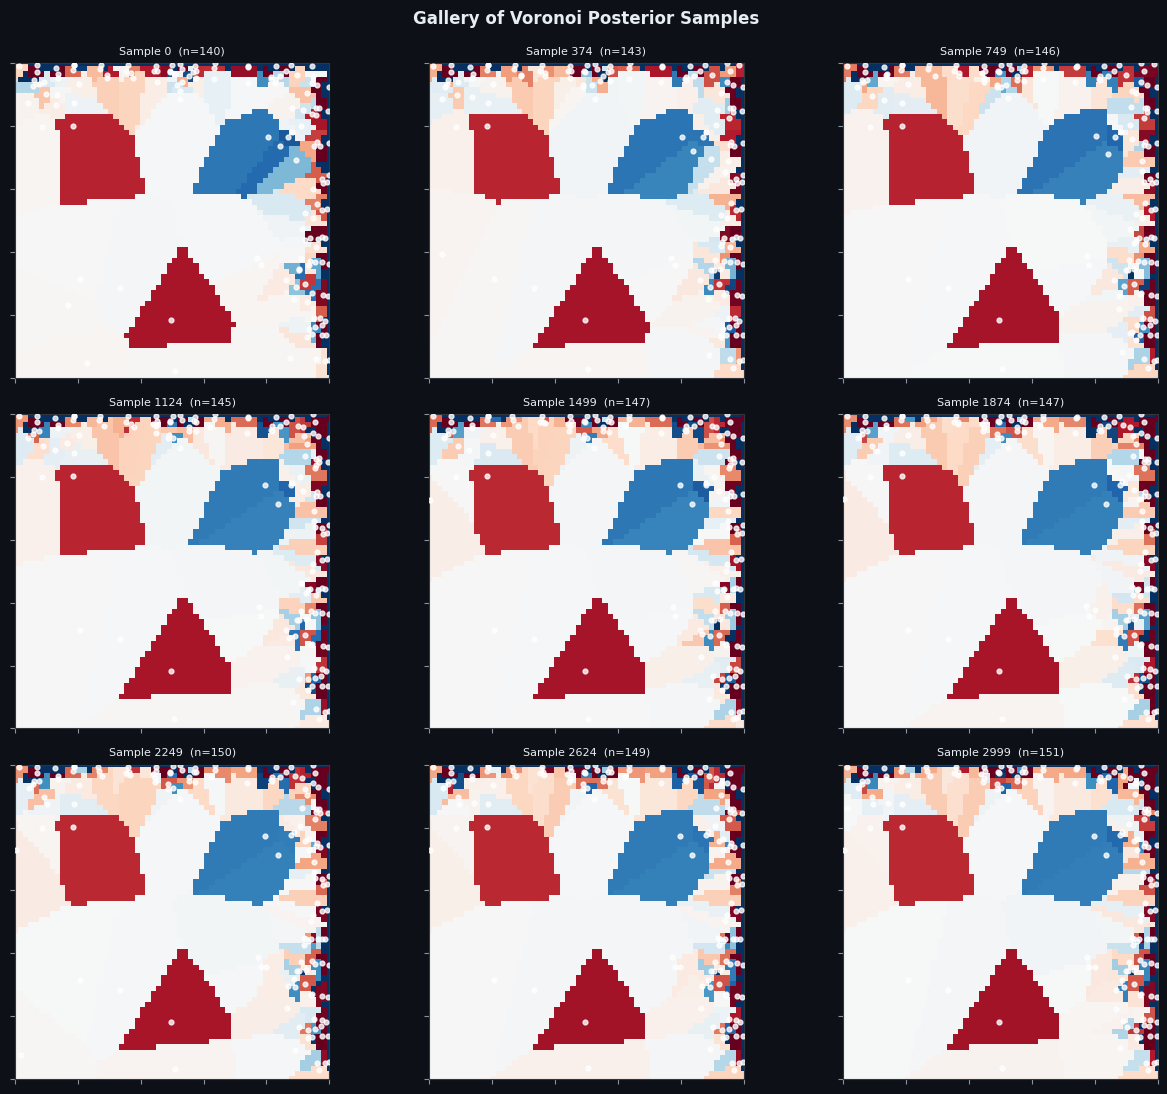

Saved → figures/voronoi_gallery.png


In [ ]:
from scipy.spatial import Voronoi, voronoi_plot_2d

def draw_voronoi_model(ax, nuclei, s_vals, title='', norm=None, cmap='RdBu_r'):
    """Render a Voronoi slowness model as a coloured pcolormesh + overlay."""
    ng = 60
    xg_ = np.linspace(0, Lx, ng); yg_ = np.linspace(0, Ly, ng)
    XG_, YG_ = np.meshgrid(xg_, yg_)
    tree = cKDTree(nuclei)
    _, idx = tree.query(np.column_stack([XG_.ravel(), YG_.ravel()]))
    s_map = s_vals[idx].reshape(ng, ng)
    ax.pcolormesh(XG_, YG_, s_map, cmap=cmap, norm=norm, shading='auto')
    ax.scatter(nuclei[:, 0], nuclei[:, 1], c='white', s=12, zorder=5, alpha=0.8)
    ax.set(xlim=(0, Lx), ylim=(0, Ly), aspect='equal')
    ax.set_title(title, color=TEXT, fontsize=8)
    ax.tick_params(labelbottom=False, labelleft=False)

# Pick 9 evenly-spaced models from the ensemble
indices  = np.linspace(0, len(ensemble)-1, 9, dtype=int)
norm_gal = TwoSlopeNorm(vmin=s_lo, vcenter=s0, vmax=s_hi)

fig, axes = plt.subplots(3, 3, figsize=(13, 11), facecolor=DARK)
for ax_row in axes:
    for ax in ax_row:
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values(): sp.set_color(BORDER)

for ax, idx in zip(axes.flat, indices):
    nuc, s = ensemble[idx]
    draw_voronoi_model(ax, nuc, s,
                       title=f'Sample {idx}  (n={len(nuc)})',
                       norm=norm_gal, cmap='RdBu_r')

fig.suptitle('Gallery of Voronoi Posterior Samples',
             color=TEXT, fontsize=12, fontweight='bold', y=0.99)
plt.tight_layout()
plt.savefig('figures/voronoi_gallery.png', dpi=110, bbox_inches='tight', facecolor=DARK)
plt.show()
print("Saved → figures/voronoi_gallery.png")


## 14 · Extensions & Next Steps

### Non-linearity (iterative linearisation)
The surrogate data were generated with straight rays.  For a fully non-linear
inversion follow the **outer loop** of Fig. 2 in the paper:
1. Compute travel times via fast marching (e.g. `scikit-fmm`) on the ensemble-mean model.
2. Extract updated ray paths.
3. Rebuild `all_pts_flat` / `ray_indices` from the new rays.
4. Re-run the rj-MCMC inner loop.
Repeat until the reference model converges.

### Computational speedups
| Idea | Benefit |
|------|---------|
| Partial update on birth/death (only update rays through changed cells) | ×2–5 speedup |
| Parallel chains (multiprocessing) | Linear speedup |
| Numba/Cython forward model | ×5–20 speedup |
| Reduced basis for ensemble projection | Smaller memory |

### Prior choices
- Log-uniform slowness prior (better-behaved for velocity)
- Gaussian process prior on slowness with spatial correlation length
- Informative prior from regional geology

### Convergence assessment
Run **multiple independent chains** from different starting points and
compare the posterior statistics — differences indicate non-convergence.
